---
title: modeling BSTR autocatalysis
author: group m1
date: today
format: 
    html:
        self-contained: true
---

the reaction is 

$$ \mathrm{Ac} + \mathrm{I_2} \longrightarrow \mathrm{AcI} + \mathrm{HI} \tag{1}$$

the limiting reagent is $\mathrm{I_2}$ from the given initial conditions. assembling a ICE table,

| species            | initial    | change       | end                   |
|:-------------------|:-----------|:-------------|:----------------------|
| $\mathrm{I_2}$     | $C_{I,0}$  | $-x C_{I,0}$ | $C_{I,0} (1-x)$       |
| $\mathrm{Acetone}$ | $C_{Ac,0}$ | $-x C_{I,0}$ | $C_{Ac,0} -x C_{I,0}$ |
| $\mathrm{H_3O^+}$  | $C_{H,0}$  | $+x C_{I,0}$ | $C_{H,0} +x C_{I,0}$  |

$$ r_{I_2} = - k \mathrm{[Ac] [I_2] [H_3O^+]} $$

from kinetics (cite robers perhaps), our BSTR design equation was

$$ \frac{d x}{dt} = \frac{k \mathrm{[Ac]^\alpha [H_3O^+]^\beta [I_2]^\gamma}}{C_{I_2,0}} $$



# plotting all

k: 0.0000859642


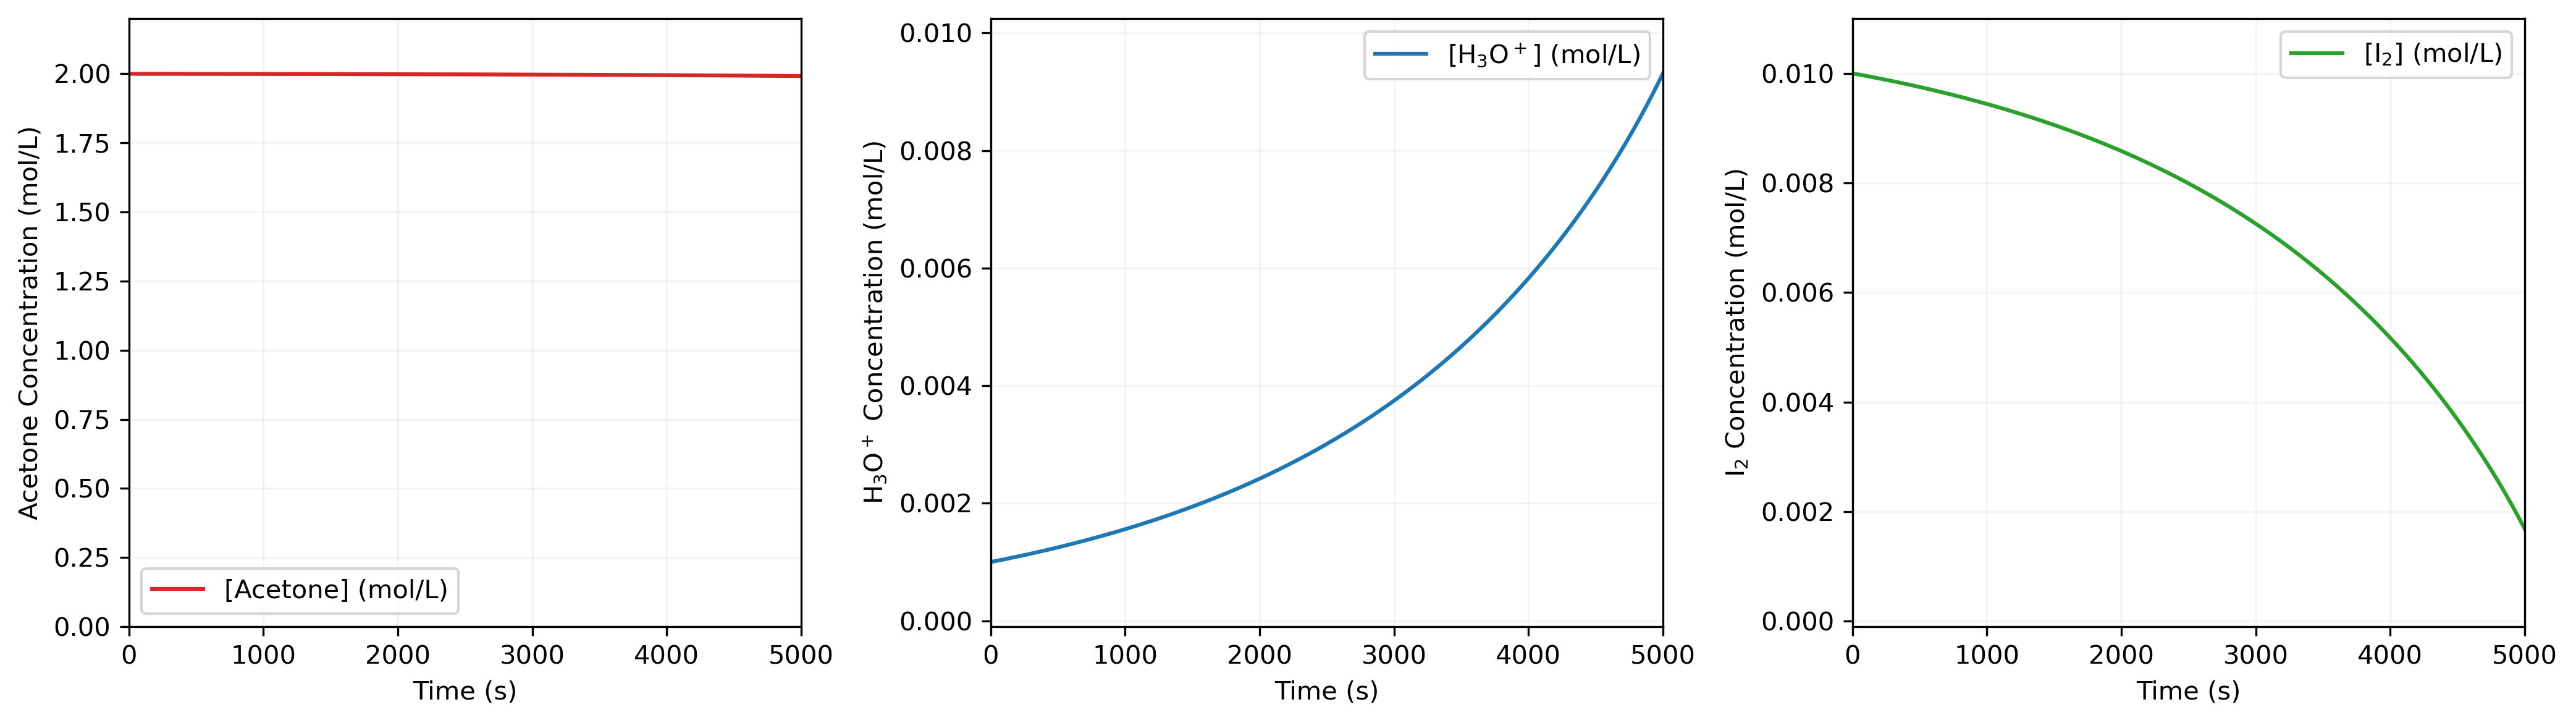

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.constants import R

# ---- kinetic parameters ----
alpha = 1.02637
beta = 0.95376
gamma = -0.13411

Ea, ln_A = 114393.7493, 36.0457 
T = 303.0 # K
k = np.exp(ln_A)*np.exp((-Ea / (R*T)))
print(f'k: {k:.10f}')

# ---- initial concentrations ----
C_I0 = 10.0e-3
C_Ac0 = 2.0
C_H0 = 1e-3

def concentrations_from_ice(x_val):
    '''use the results from the ICE table to eval concentrations'''
    C_I2 = C_I0 * (1 - x_val)
    C_Ac = C_Ac0 - x_val * C_I0
    C_H3O = C_H0 + x_val * C_I0
    return C_Ac, C_H3O, C_I2

def dxdt_equation(_t, y):
    '''rate equation for numerical simulations'''
    x_val = np.clip(y[0], 0.0, 1.0)
    C_Ac, C_H3O, C_I2 = concentrations_from_ice(x_val)
    dxdt = (
        k
        * max(C_Ac, 0.0) ** alpha
        * max(C_H3O, 0.0) ** beta
        * max(C_I2, 0.0) ** gamma
        / C_I0
    )
    return [dxdt]

sol = solve_ivp(
    dxdt_equation,
    (0, 5000),
    [0],
    max_step=1.0
)

x = np.clip(sol.y[0], 0.0, 1.0) # no negative concentrations, bruh
C_Ac_prof, C_H3O_prof, C_I2_prof = concentrations_from_ice(x)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=300, layout='tight')
for ax, conc, name, color in zip(axes, [C_Ac_prof, C_H3O_prof, C_I2_prof], 
                                 ['Acetone', 'H$_3$O$^+$', 'I$_2$'], ['tab:red', 'tab:blue', 'tab:green']):
    ax.plot(sol.t, conc, label=f'[{name}] (mol/L)', c=color)
    ax.set(xlabel='Time (s)', 
        ylabel=f'{name} Concentration (mol/L)', 
        xlim=(0,5000), ylim=(-0.0001, conc.max()*1.1))
    ax.legend()
    ax.grid(True, alpha=0.12)
plt.savefig('BSTRmodel2.pdf')

# monte carlo


k: 0.0000859676


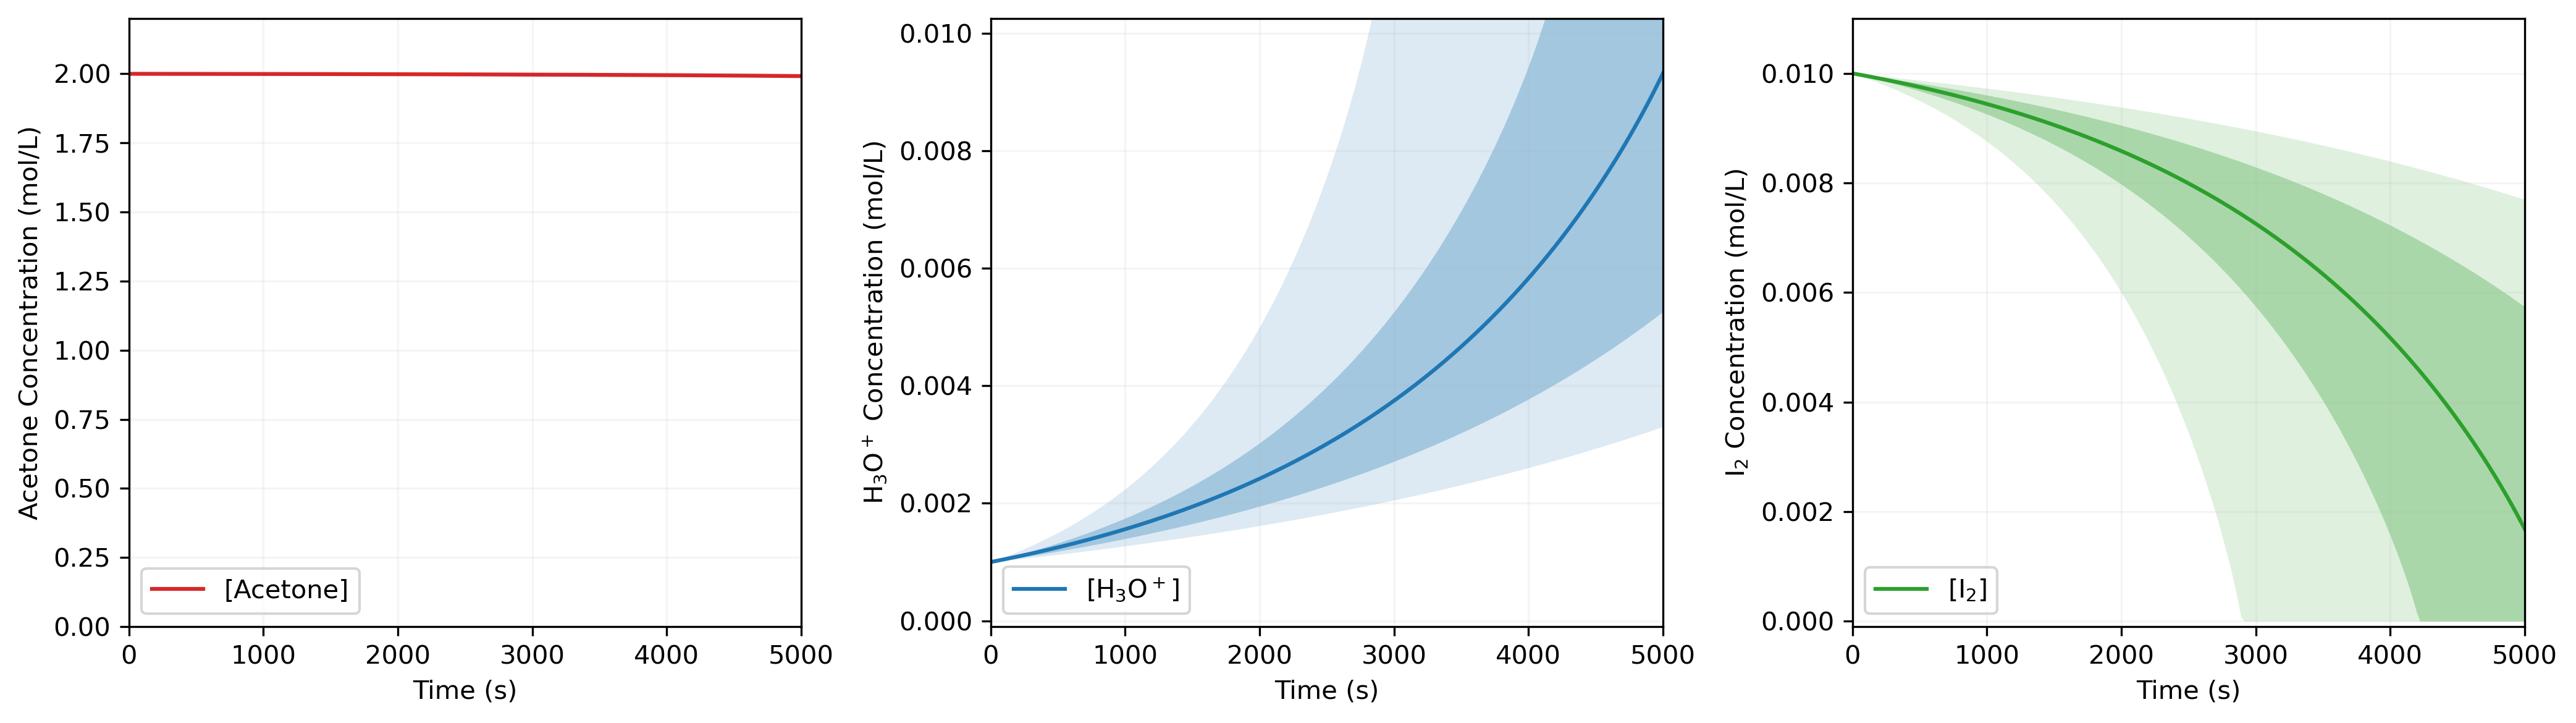

In [2]:

# ---- kinetic parameters and their standard deviations ----
alpha,  alpha_std  = 1.02637, 0
beta,   beta_std   = 0.95376, 0
gamma,  gamma_std  = -0.13411, 0
lnk, lnk_std = -9.36154, 0.38861

T = 303.0
k = np.exp(lnk)
print(f'k: {k:.10f}')

# ---- initial concentrations ----
C_I0  = 10.0e-3
C_Ac0 = 2.0
C_H0  = 1e-3

N_SAMPLES = 500  # Monte Carlo draws

def concentrations_from_ice(x_val):
    C_I2  = C_I0 * (1 - x_val)
    C_Ac  = C_Ac0 - x_val * C_I0
    C_H3O = C_H0  + x_val * C_I0
    return C_Ac, C_H3O, C_I2

def make_dxdt(k_, alpha_, beta_, gamma_):
    def dxdt_equation(_t, y):
        x_val = np.clip(y[0], 0.0, 1.0)
        C_Ac, C_H3O, C_I2 = concentrations_from_ice(x_val)
        return [k_
                * max(C_Ac,  1e-12) ** alpha_
                * max(C_H3O, 1e-12) ** beta_
                * max(C_I2,  1e-12) ** gamma_
                / C_I0]
    return dxdt_equation

# ---- nominal solution ----
sol_nom = solve_ivp(make_dxdt(k, alpha, beta, gamma),
                    (0, 5000), [0], max_step=1.0)
t_nom = sol_nom.t
x_nom = np.clip(sol_nom.y[0], 0.0, 1.0)
nom_profs = concentrations_from_ice(x_nom)  # (C_Ac, C_H3O, C_I2)

# ---- Monte Carlo ensemble ----
rng = np.random.default_rng(42)
t_grid = np.linspace(0, 5000, 200)
ensemble = [[], [], []]  # one list per species

for _ in range(N_SAMPLES):
    a_   = rng.normal(alpha,  alpha_std)
    b_   = rng.normal(beta,   beta_std)
    g_   = rng.normal(gamma,  gamma_std)
    lnk_ = rng.normal(lnk,   lnk_std)
    k_   = np.exp(lnk_) 

    try:
        sol = solve_ivp(make_dxdt(k_, a_, b_, g_),
                        (0, 5000), [0], max_step=5.0,
                        dense_output=True)
        x_g = np.clip(sol.sol(t_grid)[0], 0.0, 1.0)
        profs = concentrations_from_ice(x_g)
        for i in range(3):
            ensemble[i].append(profs[i])
    except Exception:
        pass

# percentile bands
bands = []
for i in range(3):
    arr = np.array(ensemble[i])
    bands.append({
        'p5':    np.percentile(arr,  5, axis=0),
        'p25':   np.percentile(arr, 25, axis=0),
        'p75':   np.percentile(arr, 75, axis=0),
        'p95':   np.percentile(arr, 95, axis=0),
    })

# ---- plot ----
names  = ['Acetone', 'H$_3$O$^+$', 'I$_2$']
colors = ['tab:red', 'tab:blue', 'tab:green']

fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=300, layout='tight')

for ax, nom, b, name, color in zip(axes, nom_profs, bands, names, colors):
    # 90% band (p5–p95)
    ax.fill_between(t_grid, b['p5'], b['p95'],
                    color=color, alpha=0.15, linewidth=0)
    # 50% band (p25–p75)
    ax.fill_between(t_grid, b['p25'], b['p75'],
                    color=color, alpha=0.30, linewidth=0)
    # nominal line
    ax.plot(t_nom, nom, color=color, linewidth=1.5, label=f'[{name}]')

    ax.set(xlabel='Time (s)',
           ylabel=f'{name} Concentration (mol/L)',
           xlim=(0, 5000),
           ylim=(-0.0001, nom.max() * 1.1))
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.12)

plt.savefig('BSTRmodel3.pdf')

nicer plot

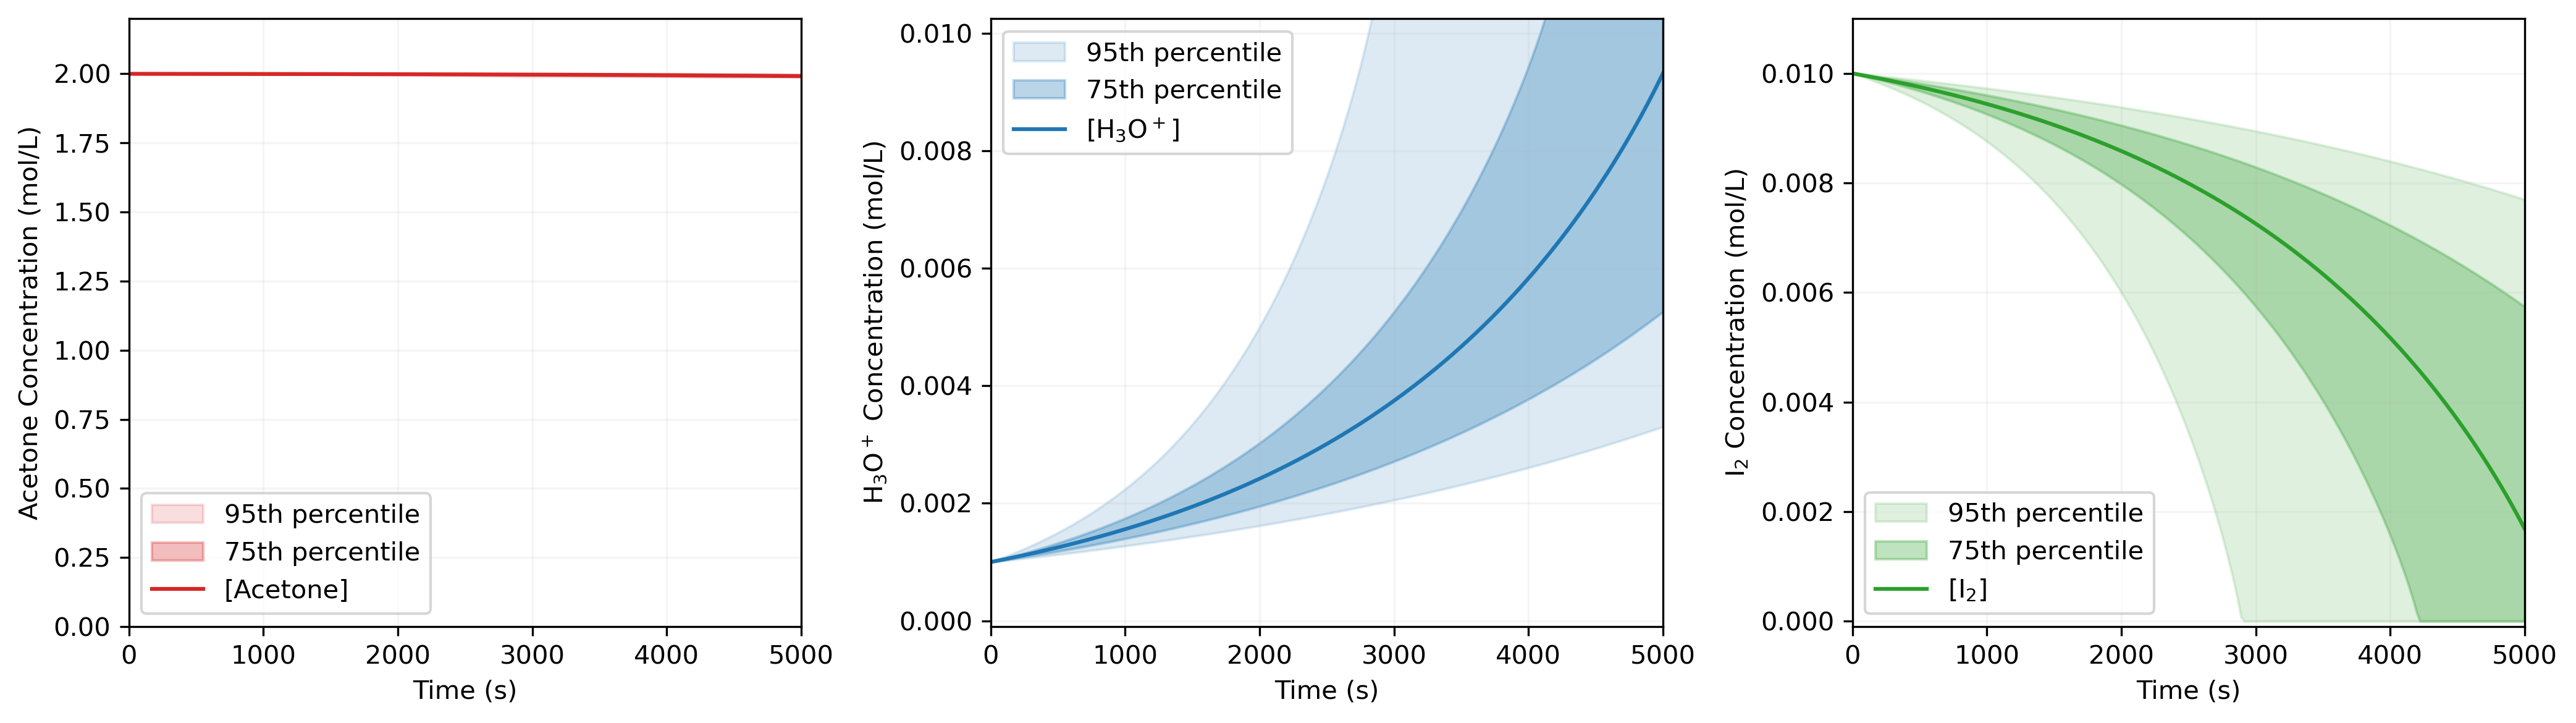

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=300, layout='tight')

for ax, nom, b, name, color in zip(axes, nom_profs, bands, names, colors):
    # 90% band (p5–p95)
    ax.fill_between(t_grid, b['p5'], b['p95'],
                    color=color, alpha=0.15, linewidth=1, label='95th percentile')
    # 50% band (p25–p75)
    ax.fill_between(t_grid, b['p25'], b['p75'],
                    color=color, alpha=0.30, linewidth=1, label='75th percentile')
    # nominal line
    ax.plot(t_nom, nom, color=color, linewidth=1.5, label=f'[{name}]')

    ax.set(xlabel='Time (s)',
           ylabel=f'{name} Concentration (mol/L)',
           xlim=(0, 5000),
           ylim=(-0.0001, nom.max() * 1.1))
    ax.legend(loc='best')
    ax.grid(True, alpha=0.12)

plt.savefig('BSTRmodel3.pdf')

In [4]:
#